### Configuraciones generales

In [1]:
NOMBRE_AUDIO = "DemoAcordeon_Short.wav" 
# Ajustar para variar la intensidad del recorte del audio
DELTA_SEGMENTS = 0.2
# Máximo de iteraciones del DE
MAX_ITERS_DE = 100
# Número de reinicios del CMA
CMA_REPEAT_TIMES = 3
# Mostrar los logs de los optimizadores
SHOW_OPTIMIZERS_LOGS = True

In [2]:
import numpy as np
from Libs.globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Libs.Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Libs.Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

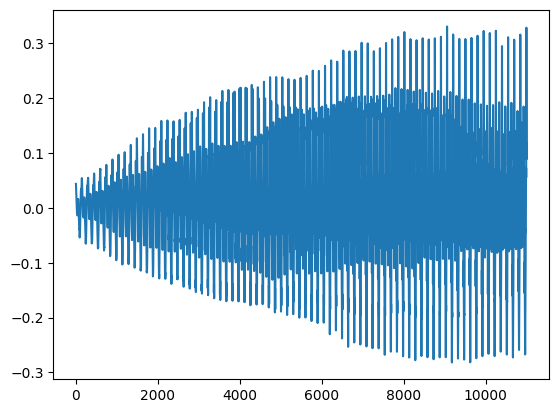

In [3]:
audio_path = f'Audios/{NOMBRE_AUDIO}'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

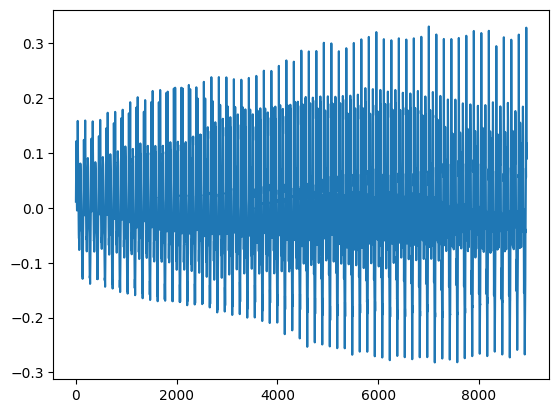

Pieces 1


In [4]:
audio_segments = split_audio(audio, SAMPLE_RATE, delta=DELTA_SEGMENTS)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [5]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Processing section', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best, _ = search_with_DE(target_C, duration, disp=SHOW_OPTIMIZERS_LOGS, maxiter=MAX_ITERS_DE)
            best, _ = search_with_CMA(target_C, duration, best, disp=SHOW_OPTIMIZERS_LOGS, repeat_times=CMA_REPEAT_TIMES)
        else:
            best, _ = search_with_CMA(target_C, duration, last_best, disp=SHOW_OPTIMIZERS_LOGS, repeat_times=CMA_REPEAT_TIMES)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Processing section 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 0.15784132776613596
differential_evolution step 2: f(x)= 0.15412628977159448
differential_evolution step 3: f(x)= 0.15412628977159448
differential_evolution step 4: f(x)= 0.15364031308882978
differential_evolution step 5: f(x)= 0.14214720089414107
differential_evolution step 6: f(x)= 0.13703303120374036
differential_evolution step 7: f(x)= 0.13703303120374036
differential_evolution step 8: f(x)= 0.13703303120374036
differential_evolution step 9: f(x)= 0.13703303120374036
differential_evolution step 10: f(x)= 0.13703303120374036
differential_evolution step 11: f(x)= 0.13703303120374036
differential_evolution step 12: f(x)= 0.13703303120374036
differential_evolution step 13: f(x)= 0.12872032207544284
differential_evolution step 14: f(x)= 0.12872032207544284
differential_evolution step 15: f(x)= 0.12872032207544284
differential_evolution step 16: f(x)= 0.12872032207544284
differential_evolution step 17: f(x)= 0.12872032207544284
differential_evolution 

In [6]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)

    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

Parámetro,Valor
osc1_shape,0.822919
osc1_phase,0.52528
osc1_volume,0.0203256
osc1_freq,525.086
osc2_shape,0.935191
osc2_phase,0.222889
osc2_volume,0.181657
osc2_freq,4992.94
osc3_shape,2.00104
osc3_phase,0.138602


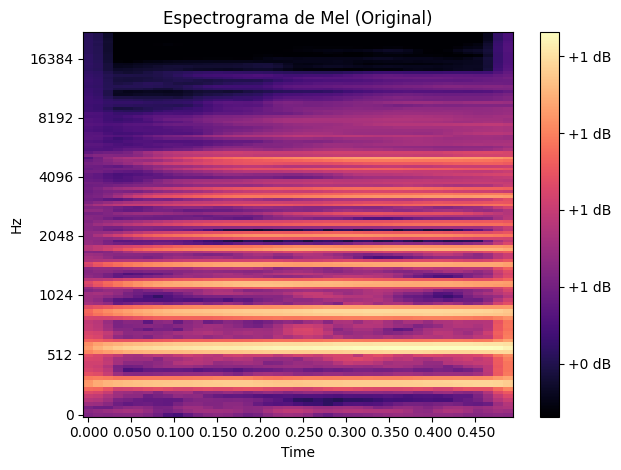

In [7]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel (Original)')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

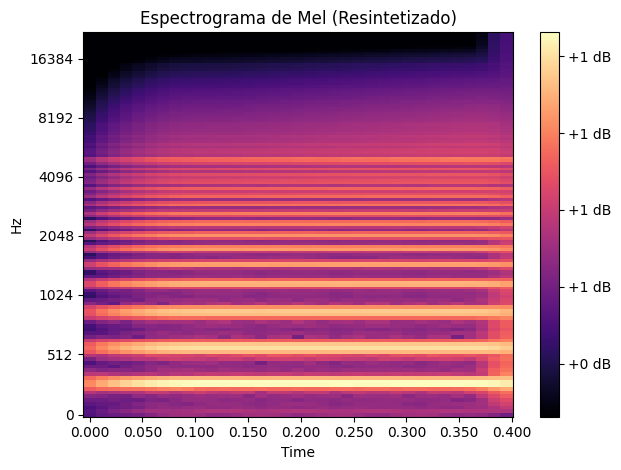

In [8]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel (Resintetizado)')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))